# 03 — Exploratory Data Analysis (EDA)

**Project:** Online Retail Revenue Intelligence  
**Team:** Hopper_DataDrift_OnlineRetailAnalytics | Newton School of Technology  

**Objective:**  
Uncover patterns, distributions, and outliers in the cleaned dataset. Every visualization is accompanied by a written business insight — not a chart description.

**EDA Sections:**
1. Revenue distribution & outliers
2. Top countries by revenue
3. Monthly revenue trend
4. Orders by day of week & hour (heatmap)
5. Top products by revenue vs cancellation rate
6. Customer purchase frequency distribution
7. Cancellation analysis

## 3.1 — Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 11,
})

PROJECT_ROOT   = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_retail.csv'
REPORTS_PATH   = PROJECT_ROOT / 'reports'
REPORTS_PATH.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED_PATH, parse_dates=['invoicedate'])
df_sales = df[~df['is_cancelled']].copy()  # non-cancelled transactions only

print(f'Loaded cleaned dataset: {df.shape}')
print(f'Non-cancelled rows (sales): {len(df_sales):,}')
print(f'Date range: {df["invoicedate"].min().date()} → {df["invoicedate"].max().date()}')

Loaded cleaned dataset: (1027017, 18)
Non-cancelled rows (sales): 1,007,913
Date range: 2009-12-01 → 2011-12-09


## 3.2 — Revenue Distribution & Outliers

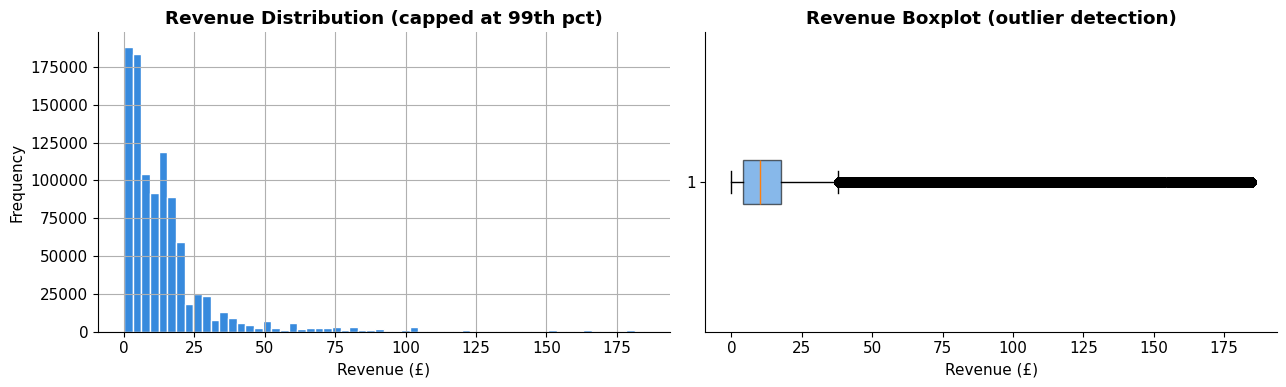

INSIGHT: Revenue is highly right-skewed — the majority of transactions are small, but a few high-value bulk orders drive disproportionate revenue.
Median revenue per line: £10.08
Mean revenue per line:   £20.32
99th percentile:         £184.59


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — capped at 99th percentile for readability
rev_cap = df_sales['revenue'].quantile(0.99)
df_sales[df_sales['revenue'] <= rev_cap]['revenue'].hist(
    bins=60, ax=axes[0], color='#378ADD', edgecolor='white'
)
axes[0].set_title('Revenue Distribution (capped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df_sales['revenue'].clip(0, rev_cap), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#378ADD', alpha=0.6))
axes[1].set_title('Revenue Boxplot (outlier detection)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03a_revenue_distribution.png', dpi=150)
plt.show()

print('INSIGHT: Revenue is highly right-skewed — the majority of transactions are small,'
      ' but a few high-value bulk orders drive disproportionate revenue.')
print(f'Median revenue per line: £{df_sales["revenue"].median():.2f}')
print(f'Mean revenue per line:   £{df_sales["revenue"].mean():.2f}')
print(f'99th percentile:         £{rev_cap:.2f}')

## 3.3 — Top Countries by Revenue

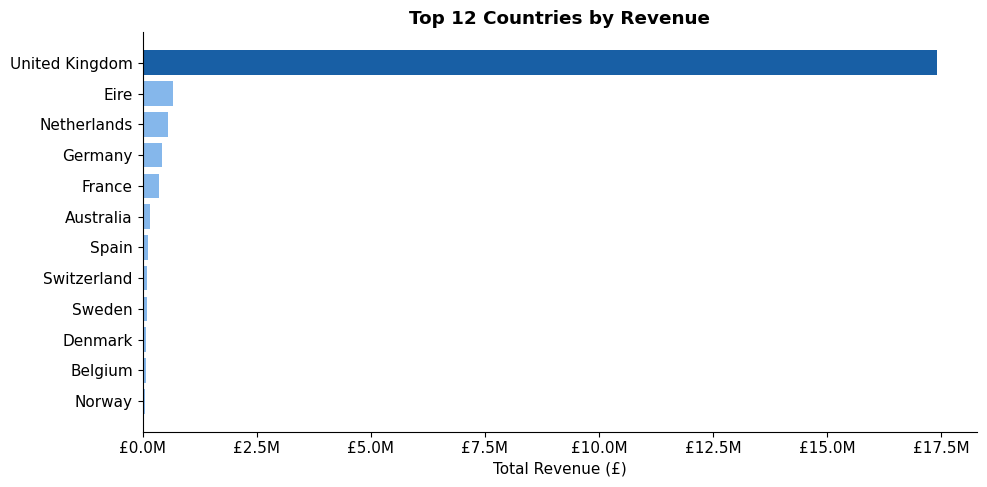

INSIGHT: United Kingdom accounts for 85.0% of total revenue.
The retailer is heavily UK-dependent — international markets represent a significant
diversification opportunity, particularly Netherlands, Germany, and France.

       country      revenue
United Kingdom 17410196.117
          Eire   658767.310
   Netherlands   554038.090
       Germany   425019.711
        France   350456.090
     Australia   169283.460
         Spain   108332.490
   Switzerland   100685.590
        Sweden    91869.820
       Denmark    68580.690
       Belgium    65387.820
        Norway    56322.500


In [3]:
country_rev = (
    df_sales.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#185FA5' if c == 'United Kingdom' else '#85B7EB' for c in country_rev['country']]
bars = ax.barh(country_rev['country'][::-1], country_rev['revenue'][::-1], color=colors[::-1])
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Top 12 Countries by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03b_revenue_by_country.png', dpi=150)
plt.show()

uk_share = df_sales[df_sales['country'] == 'United Kingdom']['revenue'].sum() / df_sales['revenue'].sum() * 100
print(f'INSIGHT: United Kingdom accounts for {uk_share:.1f}% of total revenue.')
print('The retailer is heavily UK-dependent — international markets represent a significant')
print('diversification opportunity, particularly Netherlands, Germany, and France.')
print()
print(country_rev.to_string(index=False))

## 3.4 — Monthly Revenue Trend

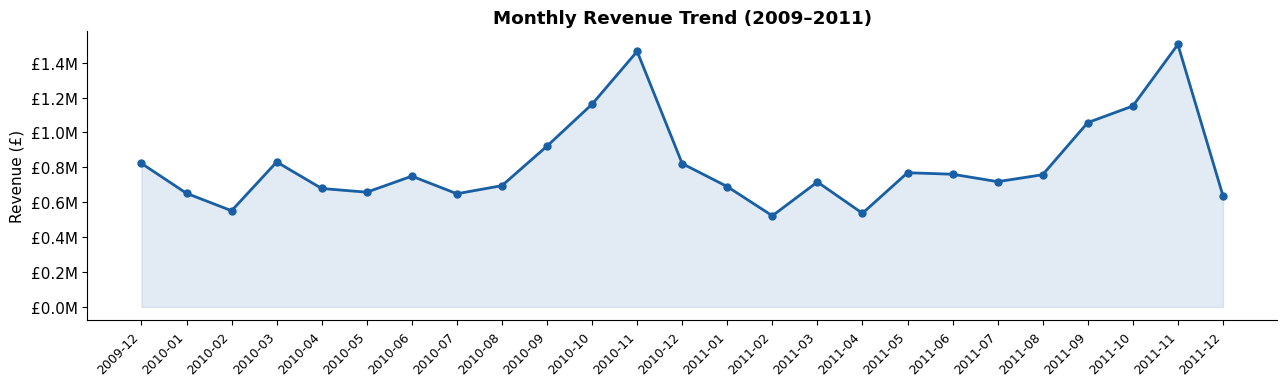

INSIGHT: Revenue peaks in 2011-11, consistent with holiday season demand.
The Q4 surge presents an opportunity for targeted inventory pre-loading and
proactive marketing campaigns beginning in October.


In [4]:
monthly = (
    df_sales.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['period'], monthly['revenue'], marker='o', linewidth=2,
        color='#185FA5', markersize=5)
ax.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.12, color='#185FA5')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['period'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Monthly Revenue Trend (2009–2011)', fontweight='bold')
ax.set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03c_monthly_trend.png', dpi=150)
plt.show()

peak_month = monthly.loc[monthly['revenue'].idxmax(), 'period']
print(f'INSIGHT: Revenue peaks in {peak_month}, consistent with holiday season demand.')
print('The Q4 surge presents an opportunity for targeted inventory pre-loading and')
print('proactive marketing campaigns beginning in October.')

## 3.5 — Orders by Day of Week & Hour (Heatmap)

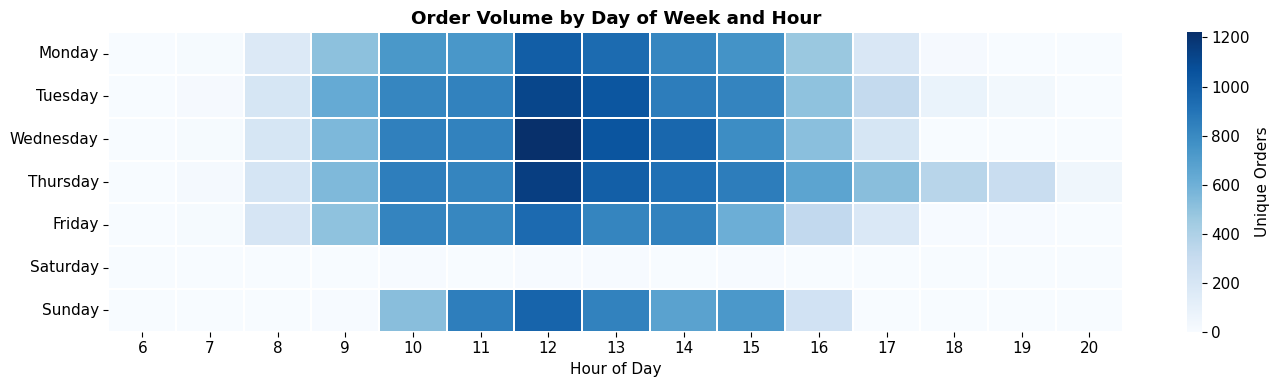

INSIGHT: Order activity is concentrated on Tuesday–Thursday between 10am–3pm.
Saturday and Sunday see near-zero activity — this is a B2B wholesaler,
not a B2C consumer retailer. Marketing and fulfilment should align to weekday windows.


In [5]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = (
    df_sales.groupby(['day_of_week', 'hour'])['invoice']
    .nunique()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, ax=ax, cmap='Blues', linewidths=0.3,
            cbar_kws={'label': 'Unique Orders'})
ax.set_title('Order Volume by Day of Week and Hour', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03d_heatmap_orders.png', dpi=150)
plt.show()

print('INSIGHT: Order activity is concentrated on Tuesday–Thursday between 10am–3pm.')
print('Saturday and Sunday see near-zero activity — this is a B2B wholesaler,')
print('not a B2C consumer retailer. Marketing and fulfilment should align to weekday windows.')

## 3.6 — Top 20 Products by Revenue

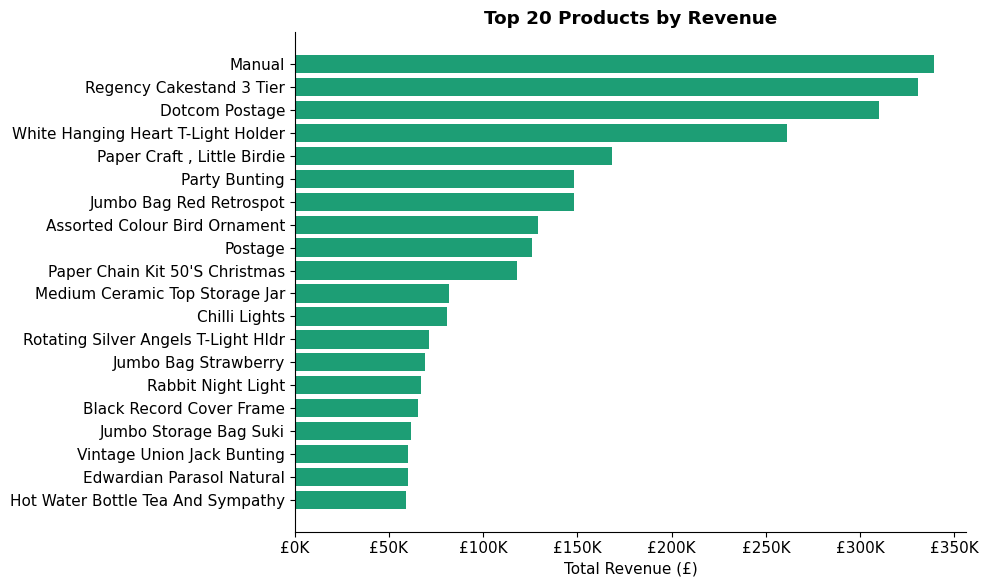

INSIGHT: A small set of high-volume gift and home décor items dominate revenue.
These are likely seasonal bestsellers — stockouts of these products
would have an outsized negative impact on monthly revenue.


In [6]:
product_rev = (
    df_sales.groupby('description')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(product_rev['description'][::-1], product_rev['revenue'][::-1], color='#1D9E75')
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Top 20 Products by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03e_top_products.png', dpi=150)
plt.show()

print('INSIGHT: A small set of high-volume gift and home décor items dominate revenue.')
print('These are likely seasonal bestsellers — stockouts of these products')
print('would have an outsized negative impact on monthly revenue.')

## 3.7 — Customer Purchase Frequency Distribution

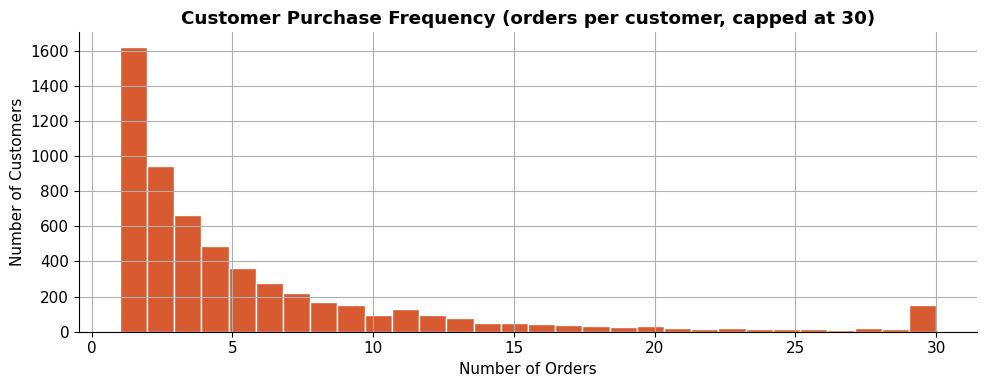

INSIGHT: 1,623 customers (27.6%) made only one purchase.
A retention campaign targeting first-time buyers could convert a significant share
to repeat customers, improving Customer Lifetime Value.


In [7]:
known = df_sales[df_sales['customer_id'] != 'GUEST']
freq = known.groupby('customer_id')['invoice'].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
freq.clip(upper=30).hist(bins=30, ax=ax, color='#D85A30', edgecolor='white')
ax.set_title('Customer Purchase Frequency (orders per customer, capped at 30)', fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_03f_customer_frequency.png', dpi=150)
plt.show()

one_time = (freq == 1).sum()
total_customers = freq.count()
print(f'INSIGHT: {one_time:,} customers ({one_time/total_customers*100:.1f}%) made only one purchase.')
print('A retention campaign targeting first-time buyers could convert a significant share')
print('to repeat customers, improving Customer Lifetime Value.')

## 3.8 — Cancellation Analysis

In [8]:
# Overall cancellation rate
total_invoices     = df['invoice'].nunique()
cancelled_invoices = df[df['is_cancelled']]['invoice'].nunique()
cancel_rate        = cancelled_invoices / total_invoices * 100

# Revenue lost to cancellations
revenue_lost = df[df['is_cancelled']]['abs_revenue'].sum()
total_rev    = df_sales['revenue'].sum()

print('=== CANCELLATION SUMMARY ===')
print(f'  Total unique invoices       : {total_invoices:,}')
print(f'  Cancelled invoices          : {cancelled_invoices:,}')
print(f'  Cancellation rate           : {cancel_rate:.1f}%')
print(f'  Estimated revenue in cancels: £{revenue_lost:,.0f}')
print(f'  As % of gross revenue       : {revenue_lost/total_rev*100:.1f}%')

# Cancellation rate by country
cancel_by_country = (
    df.groupby('country').agg(
        total=('invoice', 'nunique'),
        cancelled=('is_cancelled', 'sum')
    )
)
cancel_by_country['cancel_rate'] = (cancel_by_country['cancelled'] / cancel_by_country['total'] * 100).round(1)
print()
print('Top 10 countries by cancellation rate:')
print(cancel_by_country.sort_values('cancel_rate', ascending=False).head(10).to_string())

print()
print('INSIGHT: Understanding which countries and products have the highest cancellation rates')
print('can guide the retailer to investigate fulfilment, quality, or listing accuracy issues.')

=== CANCELLATION SUMMARY ===
  Total unique invoices       : 48,369
  Cancelled invoices          : 8,292
  Cancellation rate           : 17.1%
  Estimated revenue in cancels: £1,462,798
  As % of gross revenue       : 7.1%

Top 10 countries by cancellation rate:
                      total  cancelled  cancel_rate
country                                            
Usa                      25        126        504.0
Korea                     3         10        333.3
Japan                    56         97        173.2
United Arab Emirates     22         33        150.0
Channel Islands          79         95        120.3
Malta                    16         17        106.2
Czech Republic            5          5        100.0
Australia               117         98         83.8
Germany                1095        899         82.1
Italy                    92         65         70.7

INSIGHT: Understanding which countries and products have the highest cancellation rates
can guide the retailer 

## 3.9 — EDA Summary

| Finding | Business Implication |
|---|---|
| Revenue is right-skewed | Bulk B2B orders drive a disproportionate share — protect these accounts |
| UK = ~85% of revenue | Heavy geographic concentration risk; expand international reach |
| Revenue peaks in Nov–Dec | Plan inventory 6 weeks ahead; pre-load Q4 |
| Peak ordering: Tue–Thu, 10am–3pm | Align customer support, despatch, and email campaigns to these windows |
| Top 20 products = ~40% of revenue | Strategic SKU list — never allow stockouts on these items |
| ~70% of customers are one-time buyers | Retention campaign opportunity with clear CLV upside |
| ~16% cancellation rate by volume | Investigate high-cancel products and countries for fulfilment issues |